In [62]:
# Run this cell first to install gymnasium
# !pip install gymnasium
!pip install pillow pygame
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Test if pygame is available
try:
    import pygame
    PYGAME_AVAILABLE = True
    print("Pygame is available - visualization will work!")
except ImportError:
    PYGAME_AVAILABLE = False
    print("Pygame not available - using text-based visualization instead")

Pygame is available - visualization will work!


In [56]:
class TileCoding:
    def __init__(self, n_tilings=8, n_tiles=8):
        self.n_tilings = n_tilings
        self.n_tiles = n_tiles
        # State bounds for CartPole [pos, vel, angle, angular_vel]
        self.state_bounds = np.array([[-2.4, 2.4], [-3.0, 3.0], [-0.5, 0.5], [-2.0, 2.0]])
        self.tile_sizes = (self.state_bounds[:, 1] - self.state_bounds[:, 0]) / (n_tiles - 1)
        
    def get_tiles(self, state):
        """Get tile indices for given state"""
        tiles = []
        for tiling in range(self.n_tilings):
            # Offset each tiling
            offset = tiling * self.tile_sizes / self.n_tilings
            coords = ((state - self.state_bounds[:, 0]) / self.tile_sizes).astype(int) + offset.astype(int)
            # Ensure coordinates are within bounds
            coords = np.clip(coords, 0, self.n_tiles - 1)
            # Calculate tile index
            tile_index = tiling * (self.n_tiles ** 4) + \
                         coords[0] * (self.n_tiles ** 3) + \
                         coords[1] * (self.n_tiles ** 2) + \
                         coords[2] * self.n_tiles + \
                         coords[3]
            tiles.append(int(tile_index))
        return tiles

class SarsaLambdaAgent:
    def __init__(self, n_actions=2, n_tilings=8, lambda_=0.9, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.n_actions = n_actions
        self.lambda_ = lambda_
        self.alpha = alpha / n_tilings  # Normalize learning rate
        self.gamma = gamma
        self.epsilon = epsilon
        
        self.tile_coder = TileCoding(n_tilings, n_tiles=8)
        # Total number of tiles
        self.n_tiles_total = n_tilings * (8 ** 4)
        # Weight vector for each action
        self.weights = np.zeros((n_actions, self.n_tiles_total))
        # Eligibility traces
        self.traces = np.zeros((n_actions, self.n_tiles_total))
        
    def get_q_value(self, tiles, action):
        """Get Q-value for state-action pair"""
        return np.sum(self.weights[action][tiles])
    
    def choose_action(self, state, training=True):
        """Epsilon-greedy action selection"""
        tiles = self.tile_coder.get_tiles(state)
        
        if training and np.random.rand() < self.epsilon:
            return np.random.choice(self.n_actions)
        
        q_values = [self.get_q_value(tiles, a) for a in range(self.n_actions)]
        return np.argmax(q_values)
    
    def update(self, state, action, reward, next_state, next_action, done):
        """SARSA(λ) update"""
        # Get tiles for current and next states
        tiles = self.tile_coder.get_tiles(state)
        next_tiles = self.tile_coder.get_tiles(next_state)
        
        # Compute current and next Q-values
        q_current = self.get_q_value(tiles, action)
        q_next = 0 if done else self.get_q_value(next_tiles, next_action)
        
        # Compute TD error
        td_error = reward + self.gamma * q_next - q_current
        
        # Update eligibility traces
        self.traces *= self.gamma * self.lambda_
        self.traces[action][tiles] += 1
        
        # Update weights
        self.weights += self.alpha * td_error * self.traces
    
    def reset_traces(self):
        """Reset eligibility traces"""
        self.traces = np.zeros_like(self.traces)

In [57]:
#Cell 2: SARSA Lambda Agent Class

class SarsaLambdaAgent:
    def __init__(self, n_actions=2, n_tilings=8, lambda_=0.9, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.n_actions = n_actions
        self.lambda_ = lambda_
        self.alpha = alpha / n_tilings  # Normalize learning rate
        self.gamma = gamma
        self.epsilon = epsilon
        
        self.tile_coder = TileCoding(n_tilings, n_tiles=8)
        # Total number of tiles
        self.n_tiles_total = n_tilings * (8 ** 4)
        # Weight vector for each action
        self.weights = np.zeros((n_actions, self.n_tiles_total))
        # Eligibility traces
        self.traces = np.zeros((n_actions, self.n_tiles_total))
        
    def get_q_value(self, tiles, action):
        """Get Q-value for state-action pair"""
        return np.sum(self.weights[action][tiles])
    
    def choose_action(self, state, training=True):
        """Epsilon-greedy action selection"""
        tiles = self.tile_coder.get_tiles(state)
        
        if training and np.random.rand() < self.epsilon:
            return np.random.choice(self.n_actions)
        
        q_values = [self.get_q_value(tiles, a) for a in range(self.n_actions)]
        return np.argmax(q_values)
    
    def update(self, state, action, reward, next_state, next_action, done):
        """SARSA(λ) update"""
        # Get tiles for current and next states
        tiles = self.tile_coder.get_tiles(state)
        next_tiles = self.tile_coder.get_tiles(next_state)
        
        # Compute current and next Q-values
        q_current = self.get_q_value(tiles, action)
        q_next = 0 if done else self.get_q_value(next_tiles, next_action)
        
        # Compute TD error
        td_error = reward + self.gamma * q_next - q_current
        
        # Update eligibility traces
        self.traces *= self.gamma * self.lambda_
        self.traces[action][tiles] += 1
        
        # Update weights
        self.weights += self.alpha * td_error * self.traces
    
    def reset_traces(self):
        """Reset eligibility traces"""
        self.traces = np.zeros_like(self.traces)

In [58]:
# Cell 3: Episode and Training Functions

def run_episode(env, agent, training=True):
    """Run a single episode"""
    state, _ = env.reset()
    
    agent.reset_traces()
    action = agent.choose_action(state, training)
    
    total_reward = 0
    steps = 0
    
    while True:
        # Take action
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        total_reward += reward
        steps += 1
        
        # Choose next action (SARSA)
        next_action = agent.choose_action(next_state, training)
        
        # Update agent (only during training)
        if training:
            agent.update(state, action, reward, next_state, next_action, done)
        
        # Update state and action
        state = next_state
        action = next_action
        
        if done:
            break
    
    return total_reward, steps

def train_agent(env, agent, n_episodes=1000):
    """Train the agent"""
    rewards = []
    steps_list = []
    
    for episode in range(n_episodes):
        reward, steps = run_episode(env, agent, training=True)
        rewards.append(reward)
        steps_list.append(steps)
        
        # Decay epsilon
        if agent.epsilon > 0.01:
            agent.epsilon *= 0.995
        
        # Print progress
        if (episode + 1) % 100 == 0:
            avg_reward = np.mean(rewards[-100:])
            print(f"Episode {episode+1}/{n_episodes}, Average Reward: {avg_reward:.2f}")
    
    return rewards, steps_list

def test_agent(env, agent, n_episodes=100):
    """Test the trained agent"""
    rewards = []
    for _ in range(n_episodes):
        reward, _ = run_episode(env, agent, training=False)
        rewards.append(reward)
    return np.mean(rewards), np.std(rewards)

def visualize_agent(env, agent, num_episodes=3):
    """Visualize the trained agent"""
    render_env = gym.make('CartPole-v1', render_mode='human')
    
    for episode in range(num_episodes):
        state, _ = render_env.reset()
        agent.reset_traces()
        action = agent.choose_action(state, training=False)
        
        total_reward = 0
        steps = 0
        
        print(f"Episode {episode + 1}:")
        
        while True:
            next_state, reward, terminated, truncated, _ = render_env.step(action)
            done = terminated or truncated
            
            total_reward += reward
            steps += 1
            
            # Choose next action
            next_action = agent.choose_action(next_state, training=False)
            
            # Update state and action
            state = next_state
            action = next_action
            
            # Print state information
            if steps % 20 == 0 or done:
                print(f"  Step {steps}: Position={state[0]:.2f}, Angle={state[2]:.2f}, Action={action}")
            
            if done:
                print(f"  Episode finished after {steps} steps with total reward {total_reward}")
                print()
                break
            
            # Add a small delay to make visualization easier to follow
            time.sleep(0.05)
    
    render_env.close()

In [59]:
#Cell 4: Main Execution


# Create environment
env = gym.make('CartPole-v1')

# Create agent
agent = SarsaLambdaAgent(
    n_actions=env.action_space.n,
    n_tilings=8,
    lambda_=0.9,
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0
)

# Train agent
print("Training SARSA(λ) agent...")
train_rewards, train_steps = train_agent(env, agent, n_episodes=1000)

# Test agent
print("\nTesting trained agent...")
mean_reward, std_reward = test_agent(env, agent, n_episodes=100)
print(f"Test Results: Mean={mean_reward:.2f}, Std={std_reward:.2f}")

# Close training environment
env.close()

Training SARSA(λ) agent...
Episode 100/1000, Average Reward: 35.51
Episode 200/1000, Average Reward: 71.02
Episode 300/1000, Average Reward: 96.52
Episode 400/1000, Average Reward: 124.70
Episode 500/1000, Average Reward: 216.86
Episode 600/1000, Average Reward: 193.72
Episode 700/1000, Average Reward: 192.24
Episode 800/1000, Average Reward: 254.83
Episode 900/1000, Average Reward: 260.90
Episode 1000/1000, Average Reward: 291.67

Testing trained agent...
Test Results: Mean=361.84, Std=109.57


In [ ]:
# Basic Visualization (Text-based) - Use this if pygame is not available

def visualize_agent_text(env_name, agent, num_episodes=3):
    """Visualize the trained agent with text output"""
    # Create environment
    env = gym.make(env_name)
    
    for episode in range(num_episodes):
        state, _ = env.reset()
        agent.reset_traces()
        action = agent.choose_action(state, training=False)
        
        total_reward = 0
        steps = 0
        
        print(f"Episode {episode + 1}:")
        print("Step | Position | Velocity | Angle | Angular Vel | Action")
        print("-" * 60)
        
        while True:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            total_reward += reward
            steps += 1
            
            # Choose next action
            next_action = agent.choose_action(next_state, training=False)
            
            # Print state information every 20 steps
            if steps % 20 == 1 or done:
                print(f"{steps:4d} | {state[0]:8.3f} | {state[1]:8.3f} | {state[2]:6.3f} | {state[3]:11.3f} | {action}")
            
            # Update state and action
            state = next_state
            action = next_action
            
            if done:
                print(f"  Episode finished after {steps} steps with total reward {total_reward}")
                print()
                break
    
    env.close()

# Run text-based visualization
print("Visualizing trained agent performance (text-based)...")
visualize_agent_text('CartPole-v1', agent, num_episodes=3)

Visualizing trained agent performance (text-based)...
Episode 1:
Step | Position | Velocity | Angle | Angular Vel | Action
------------------------------------------------------------
   1 |    0.020 |   -0.012 |  0.016 |       0.024 | 1
  21 |    0.018 |    0.005 | -0.030 |      -0.349 | 1
  41 |   -0.132 |    0.027 | -0.036 |      -0.831 | 1
  61 |   -0.374 |   -0.343 | -0.077 |      -0.709 | 0
  81 |   -0.883 |   -0.730 |  0.132 |      -0.179 | 1
 101 |   -1.000 |   -0.740 | -0.110 |       0.040 | 0
 113 |   -1.379 |   -2.684 |  0.172 |       2.844 | 0
  Episode finished after 113 steps with total reward 113.0

Episode 2:
Step | Position | Velocity | Angle | Angular Vel | Action
------------------------------------------------------------
   1 |    0.035 |    0.041 | -0.043 |      -0.022 | 1
  21 |    0.039 |   -0.327 | -0.116 |       0.073 | 0
  41 |   -0.173 |   -1.085 | -0.055 |       0.734 | 1
  61 |   -0.455 |   -0.285 | -0.060 |      -0.869 | 0
  81 |   -0.949 |   -0.671 |  0.

Analyzing agent performance...


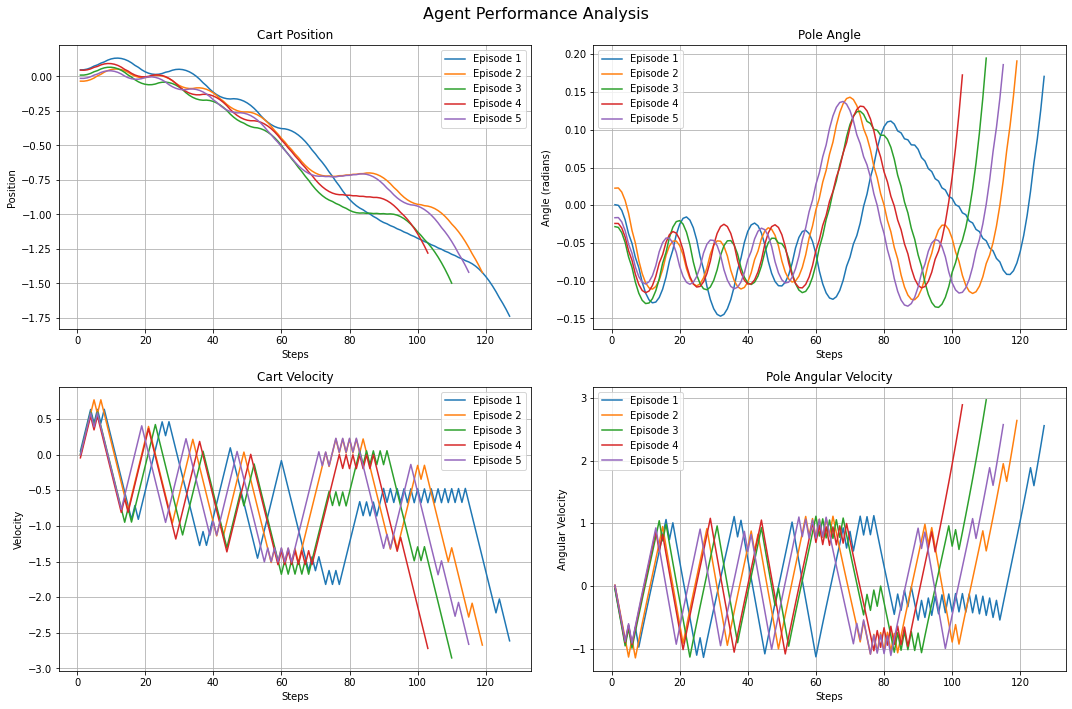

Performance Summary over 5 episodes:
Average Reward: 114.80 ± 8.11
Average Steps: 114.80 ± 8.11
Max Reward: 127.0
Min Reward: 103.0


In [48]:
# Alternative Visualization with Matplotlib (No Rendering Required)
def plot_agent_performance(agent, num_episodes=5):
    """Plot agent performance with state tracking"""
    env = gym.make('CartPole-v1')
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Agent Performance Analysis', fontsize=16)
    
    all_rewards = []
    all_steps = []
    
    for episode in range(num_episodes):
        state, _ = env.reset()
        agent.reset_traces()
        action = agent.choose_action(state, training=False)
        
        # Track states for this episode
        positions = []
        angles = []
        velocities = []
        angular_velocities = []
        steps_list = []
        
        total_reward = 0
        steps = 0
        
        while True:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            total_reward += reward
            steps += 1
            
            # Store state information
            positions.append(state[0])
            velocities.append(state[1])
            angles.append(state[2])
            angular_velocities.append(state[3])
            steps_list.append(steps)
            
            # Choose next action
            next_action = agent.choose_action(next_state, training=False)
            
            # Update state and action
            state = next_state
            action = next_action
            
            if done:
                break
        
        all_rewards.append(total_reward)
        all_steps.append(steps)
        
        # Plot for this episode
        axes[0, 0].plot(steps_list, positions, label=f'Episode {episode+1}')
        axes[0, 1].plot(steps_list, angles, label=f'Episode {episode+1}')
        axes[1, 0].plot(steps_list, velocities, label=f'Episode {episode+1}')
        axes[1, 1].plot(steps_list, angular_velocities, label=f'Episode {episode+1}')
    
    # Format plots
    axes[0, 0].set_title('Cart Position')
    axes[0, 0].set_xlabel('Steps')
    axes[0, 0].set_ylabel('Position')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    axes[0, 1].set_title('Pole Angle')
    axes[0, 1].set_xlabel('Steps')
    axes[0, 1].set_ylabel('Angle (radians)')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    axes[1, 0].set_title('Cart Velocity')
    axes[1, 0].set_xlabel('Steps')
    axes[1, 0].set_ylabel('Velocity')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    axes[1, 1].set_title('Pole Angular Velocity')
    axes[1, 1].set_xlabel('Steps')
    axes[1, 1].set_ylabel('Angular Velocity')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"Performance Summary over {num_episodes} episodes:")
    print(f"Average Reward: {np.mean(all_rewards):.2f} ± {np.std(all_rewards):.2f}")
    print(f"Average Steps: {np.mean(all_steps):.2f} ± {np.std(all_steps):.2f}")
    print(f"Max Reward: {np.max(all_rewards)}")
    print(f"Min Reward: {np.min(all_rewards)}")
    
    env.close()

# Run performance analysis
print("Analyzing agent performance...")
plot_agent_performance(agent, num_episodes=5)

Creating state animation...


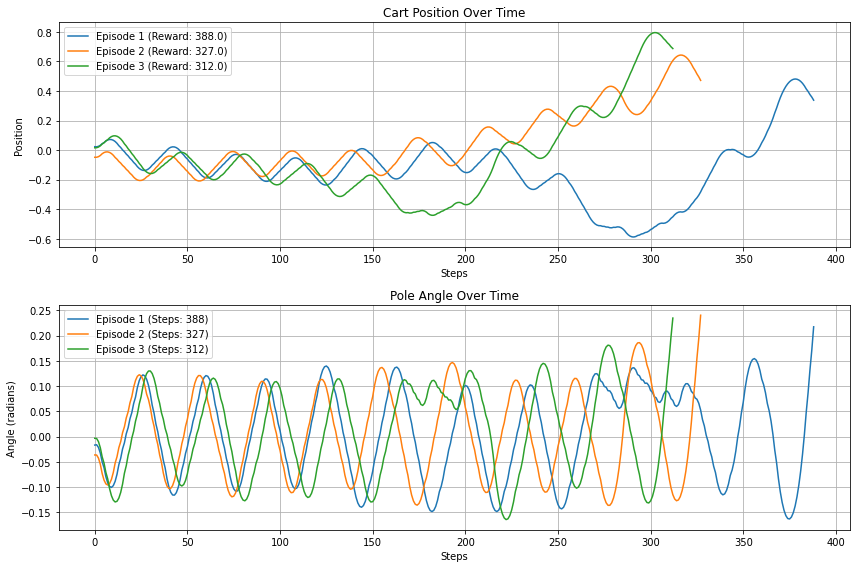

In [60]:
def animate_cartpole_states(agent, num_episodes=2):
    """Create simple animation of cartpole states"""
    env = gym.make('CartPole-v1')
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    for episode in range(num_episodes):
        state, _ = env.reset()
        agent.reset_traces()
        action = agent.choose_action(state, training=False)
        
        # Store data for plotting
        positions = [state[0]]
        angles = [state[2]]
        times = [0]
        
        total_reward = 0
        steps = 0
        
        while True:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            total_reward += reward
            steps += 1
            
            # Store state
            positions.append(next_state[0])
            angles.append(next_state[2])
            times.append(steps)
            
            # Choose next action
            next_action = agent.choose_action(next_state, training=False)
            
            # Update state and action
            state = next_state
            action = next_action
            
            if done:
                break
        
        # Plot the data
        ax1.plot(times, positions, label=f'Episode {episode+1} (Reward: {total_reward})')
        ax2.plot(times, angles, label=f'Episode {episode+1} (Steps: {steps})')
    
    ax1.set_title('Cart Position Over Time')
    ax1.set_xlabel('Steps')
    ax1.set_ylabel('Position')
    ax1.legend()
    ax1.grid(True)
    
    ax2.set_title('Pole Angle Over Time')
    ax2.set_xlabel('Steps')
    ax2.set_ylabel('Angle (radians)')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    env.close()

# Run simple animation
print("Creating state animation...")
animate_cartpole_states(agent, num_episodes=3)

In [63]:
def create_cartpole_gif(agent, max_steps=300):
    """Create a GIF-like visualization using rgb_array rendering"""
    if not PYGAME_AVAILABLE:
        print("Pygame not available for rendering")
        return
    
    try:
        # Create environment with rgb_array rendering
        env = gym.make('CartPole-v1', render_mode='rgb_array')
        
        # Setup matplotlib for animation
        import matplotlib.pyplot as plt
        from matplotlib.animation import FuncAnimation
        from IPython.display import HTML
        
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.axis('off')
        
        # Initialize
        state, _ = env.reset()
        img = ax.imshow(env.render())
        ax.set_title('CartPole Agent in Action')
        
        def update(frame):
            nonlocal state
            # Get action from agent
            action = agent.choose_action(state, training=False)
            
            # Take action
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Update image
            img.set_array(env.render())
            
            # Update title with state info
            ax.set_title(f'Step: {frame} | Position: {state[0]:.2f} | Angle: {state[2]:.3f}')
            
            # Update state
            state = next_state
            
            if done or frame >= max_steps:
                env.close()
                return [img]
            
            return [img]
        
        # Create animation
        anim = FuncAnimation(fig, update, frames=max_steps, interval=50, blit=False, repeat=False)
        
        # Show animation
        plt.tight_layout()
        html_anim = HTML(anim.to_jshtml())
        plt.close()
        
        print("Animation created successfully!")
        return html_anim
        
    except Exception as e:
        print(f"Error creating animation: {e}")
        env.close()
        return None

# Try to create animation
if PYGAME_AVAILABLE:
    print("Creating CartPole animation...")
    animation = create_cartpole_gif(agent)
    if animation:
        display(animation)
else:
    print("Cannot create animation without pygame")

Creating CartPole animation...
Animation created successfully!
